# LightGBM

## 1. Импорты и конфигурация

In [6]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

RANDOM_STATE = 42
DATA_PATH    = Path('../../data/train_data_v2.csv')
MODELS_DIR   = Path('../../models')
MODELS_DIR.mkdir(exist_ok=True)

## 2. Загрузка данных и признаки

In [7]:
df = pd.read_csv(DATA_PATH)
print(f'Датасет: {df.shape[0]} строк x {df.shape[1]} колонок')
print(f'Таргет: min={df["target"].min():.4f}  max={df["target"].max():.4f}  mean={df["target"].mean():.4f}')

BINARY_FEATURES = [
    'is_24_7', 'contactless_tech', 'qr_codes', 'usd_available', 'eur_available',
    'cash_in', 'cash_out', 'cashless_pay', 'account_statement', 'access_for_disabled',
    'transfer_p2p', 'transfer_a2a', 'loan_payments',
    'is_federal_city', 'is_federal_district_capital', 'is_city_center', 'has_subway_nearby',
]

DISTANCE_FEATURES = [
    'nearest_malls_dist_m', 'nearest_supermarkets_dist_m',
    'nearest_pharmacies_hospitals_dist_m', 'nearest_cafes_dist_m',
    'nearest_restaurants_dist_m', 'nearest_public_transport_dist_m',
    'nearest_parking_dist_m', 'nearest_education_dist_m', 'nearest_subway_dist_m',
    'nearest_post_offices_dist_m', 'nearest_offices_dist_m',
    'nearest_shops_food_small_dist_m', 'nearest_fitness_sport_dist_m',
    'nearest_hotels_hostels_dist_m', 'land_use_dist_m', 'city_center_dist_m',
    'nearest_residential_landuse_dist_m',
]

COUNT_FEATURES = [
    'count_malls_300m', 'count_supermarkets_300m', 'count_pharmacies_hospitals_300m',
    'count_banks_atms_300m', 'count_cafes_300m', 'count_restaurants_300m',
    'count_public_transport_300m', 'count_parking_300m', 'count_education_300m',
    'count_post_offices_300m', 'count_offices_300m', 'count_payment_terminals_300m',
    'count_money_transfer_300m', 'count_shops_food_small_300m', 'count_hypermarkets_300m',
    'count_markets_300m', 'count_fitness_sport_300m', 'count_hotels_hostels_300m',
    'count_railway_stations_300m', 'count_residential_buildings_300m',
    'count_residential_landuse_300m', 'count_fuel_300m',
    'count_highway_pedestrian_300m', 'count_landuse_mix_300m', 'count_footway_100m_100m',
]

ECONOMIC_FEATURES = [
    'avg_salary_oct_2025_rub', 'grp_per_capita_2023_rub',
    'avg_income_q3_2025_rub', 'population_density_per_km2',
]

CATEGORICAL_FEATURES = ['federal_district', 'city_size_category', 'land_use_type', 'atm_group']

ALL_FEATURES = (
    BINARY_FEATURES + DISTANCE_FEATURES + COUNT_FEATURES +
    ECONOMIC_FEATURES + CATEGORICAL_FEATURES
)
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]
print(f'Итого признаков : {len(ALL_FEATURES)}')
print(f'  Бинарных      : {len(BINARY_FEATURES)}')
print(f'  Расстояний    : {len(DISTANCE_FEATURES)}')
print(f'  Count (300m)  : {len(COUNT_FEATURES)}')
print(f'  Экономических : {len(ECONOMIC_FEATURES)}')
print(f'  Категориальных: {len(CATEGORICAL_FEATURES)}')

Датасет: 6200 строк x 134 колонок
Таргет: min=-0.1450  max=0.2186  mean=0.0008
Итого признаков : 67
  Бинарных      : 17
  Расстояний    : 17
  Count (300m)  : 25
  Экономических : 4
  Категориальных: 4


## 3. Подготовка данных

**Разбивка train / val / test = 70% / 15% / 15%**  
- Optuna и early stopping оптимизируют по **val** - модель не видит test до финального отчёта  
- Финальные метрики считаются один раз на **test**

In [8]:
X = df[ALL_FEATURES].copy()
y = df['target'].values

for col in BINARY_FEATURES:
    if col in X.columns and X[col].dtype == bool:
        X[col] = X[col].astype(int)

for col in DISTANCE_FEATURES:
    if col in X.columns:
        X[col] = np.log1p(X[col].clip(lower=0))

strat_col = df['city_size_category'].fillna('unknown')

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=strat_col,
)
strat_trainval = strat_col.loc[X_trainval.index]
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15 / 0.85,
    random_state=RANDOM_STATE,
    stratify=strat_trainval,
)

# Fit imputer on train only to prevent data leak
num_cols = [c for c in BINARY_FEATURES + DISTANCE_FEATURES + COUNT_FEATURES + ECONOMIC_FEATURES if c in X_train.columns]
imp = SimpleImputer(strategy='median')
X_train.loc[:, num_cols]    = imp.fit_transform(X_train[num_cols])
X_val.loc[:, num_cols]      = imp.transform(X_val[num_cols])
X_test.loc[:, num_cols]     = imp.transform(X_test[num_cols])
X_trainval.loc[:, num_cols] = imp.transform(X_trainval[num_cols])

cat_cols = [c for c in CATEGORICAL_FEATURES if c in X_train.columns]
for split in [X_train, X_val, X_test, X_trainval]:
    for col in cat_cols:
        split[col] = split[col].fillna('unknown').astype('category')

print(f'Train : {X_train.shape}  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Val   : {X_val.shape}  ({len(X_val)/len(X)*100:.0f}%)')
print(f'Test  : {X_test.shape}  ({len(X_test)/len(X)*100:.0f}%)')

Train : (4339, 67)  (70%)
Val   : (931, 67)  (15%)
Test  : (930, 67)  (15%)


In [9]:
def report_metrics(model_name, model, X_tr, y_tr, X_te, y_te, fit_time):
    t0 = time.perf_counter()
    y_pred_train = model.predict(X_tr)
    train_pred_time = time.perf_counter() - t0
    t0 = time.perf_counter()
    y_pred_test = model.predict(X_te)
    test_pred_time = time.perf_counter() - t0
    def _m(yt, yp):
        return {'RMSE': round(float(np.sqrt(mean_squared_error(yt, yp))), 4),
                'MAE':  round(float(mean_absolute_error(yt, yp)), 4),
                'R2':   round(float(r2_score(yt, yp)), 4)}
    train_m = _m(y_tr, y_pred_train)
    test_m  = _m(y_te, y_pred_test)
    table = pd.DataFrame([
        {'Split': 'Train', **train_m, 'Fit time, s': round(fit_time, 2), 'Predict time, s': round(train_pred_time, 4)},
        {'Split': 'Test',  **test_m,  'Fit time, s': float('nan'),        'Predict time, s': round(test_pred_time, 4)},
    ]).set_index('Split')
    print(f'\n{model_name}')
    display(table.style.format(
        {'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R2': '{:.4f}',
         'Fit time, s': '{:.2f}', 'Predict time, s': '{:.4f}'},
        na_rep='-'
    ))
    return {
        'Model': model_name,
        'Test RMSE': test_m['RMSE'], 'Test MAE': test_m['MAE'], 'Test R2': test_m['R2'],
        'Fit time, s': round(fit_time, 2), 'Predict time, s': round(test_pred_time, 4),
    }

## 4. Baseline LightGBM

In [5]:
t0 = time.perf_counter()
model_base = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=63,
    random_state=RANDOM_STATE,
    verbosity=-1,
)
model_base.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(200)],
)
fit_time_base = time.perf_counter() - t0

base_m = report_metrics('Baseline LightGBM', model_base, X_train, y_train, X_test, y_test, fit_time_base)
rmse_base = base_m['Test RMSE']
mae_base  = base_m['Test MAE']
r2_base   = base_m['Test R2']
print(f'Best iteration: {model_base.best_iteration_}')

[200]	valid_0's l2: 0.0020141

Baseline LightGBM


,RMSE,MAE,R2,"Fit time, s","Predict time, s"
Split,,,,,
Train,0.0292,0.0226,0.8855,1.37,0.0076
Test,0.0452,0.0360,0.7259,-,0.0045


Best iteration: 259


## 5. Подбор гиперпараметров (Optuna, 100 trials)

In [6]:
def objective(trial):
    params = {
        'n_estimators':      1000,
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 200),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state':      RANDOM_STATE,
        'verbosity':         -1,
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
    )
    preds = model.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, preds))

study = optuna.create_study(
    direction='minimize',
    study_name='lightgbm',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
print('Запускаем Optuna (100 trials)...')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'\nBest RMSE (val): {study.best_value:.4f}')
print('Best params:', study.best_params)

Запускаем Optuna (100 trials)...


  0%|          | 0/100 [00:00<?, ?it/s]


Best RMSE (val): 0.0437
Best params: {'learning_rate': 0.035872281724190797, 'num_leaves': 200, 'max_depth': 10, 'min_child_samples': 49, 'subsample': 0.9859416426623632, 'colsample_bytree': 0.9701831424339988, 'reg_alpha': 7.252647961140868e-05, 'reg_lambda': 4.429714475386216e-08}


## 6. Финальная модель

In [7]:
bp = study.best_params

t0 = time.perf_counter()
model_final = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=bp['learning_rate'],
    num_leaves=bp['num_leaves'],
    max_depth=bp['max_depth'],
    min_child_samples=bp['min_child_samples'],
    subsample=bp['subsample'],
    colsample_bytree=bp['colsample_bytree'],
    reg_alpha=bp['reg_alpha'],
    reg_lambda=bp['reg_lambda'],
    random_state=RANDOM_STATE,
    verbosity=-1,
)
model_final.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(200)],
)
fit_time_final = time.perf_counter() - t0

final_m = report_metrics('Final LightGBM (Optuna)', model_final, X_train, y_train, X_test, y_test, fit_time_final)
rmse_final = final_m['Test RMSE']
mae_final  = final_m['Test MAE']
r2_final   = final_m['Test R2']
print(f'Best iteration: {model_final.best_iteration_}')

[200]	valid_0's l2: 0.00192538
[400]	valid_0's l2: 0.00191062

Final LightGBM (Optuna)


,RMSE,MAE,R2,"Fit time, s","Predict time, s"
Split,,,,,
Train,0.0232,0.0180,0.9276,0.34,0.0189
Test,0.0448,0.0353,0.7307,-,0.0054


Best iteration: 428


## 7. Финальная модель для сохранения

In [8]:
model_save = lgb.LGBMRegressor(
    n_estimators=model_final.best_iteration_,
    learning_rate=bp['learning_rate'],
    num_leaves=bp['num_leaves'],
    max_depth=bp['max_depth'],
    min_child_samples=bp['min_child_samples'],
    subsample=bp['subsample'],
    colsample_bytree=bp['colsample_bytree'],
    reg_alpha=bp['reg_alpha'],
    reg_lambda=bp['reg_lambda'],
    random_state=RANDOM_STATE,
    verbosity=-1,
)
model_save.fit(X_trainval, y_trainval)

save_path = str(MODELS_DIR / 'lightgbm_best.txt')
model_save.booster_.save_model(save_path)
print(f'Model saved -> {save_path}')
print(f'Trained on train+val, iterations: {model_final.best_iteration_}')

Model saved -> ..\models\lightgbm_best.txt
Trained on train+val, iterations: 428


## 8. Важность признаков

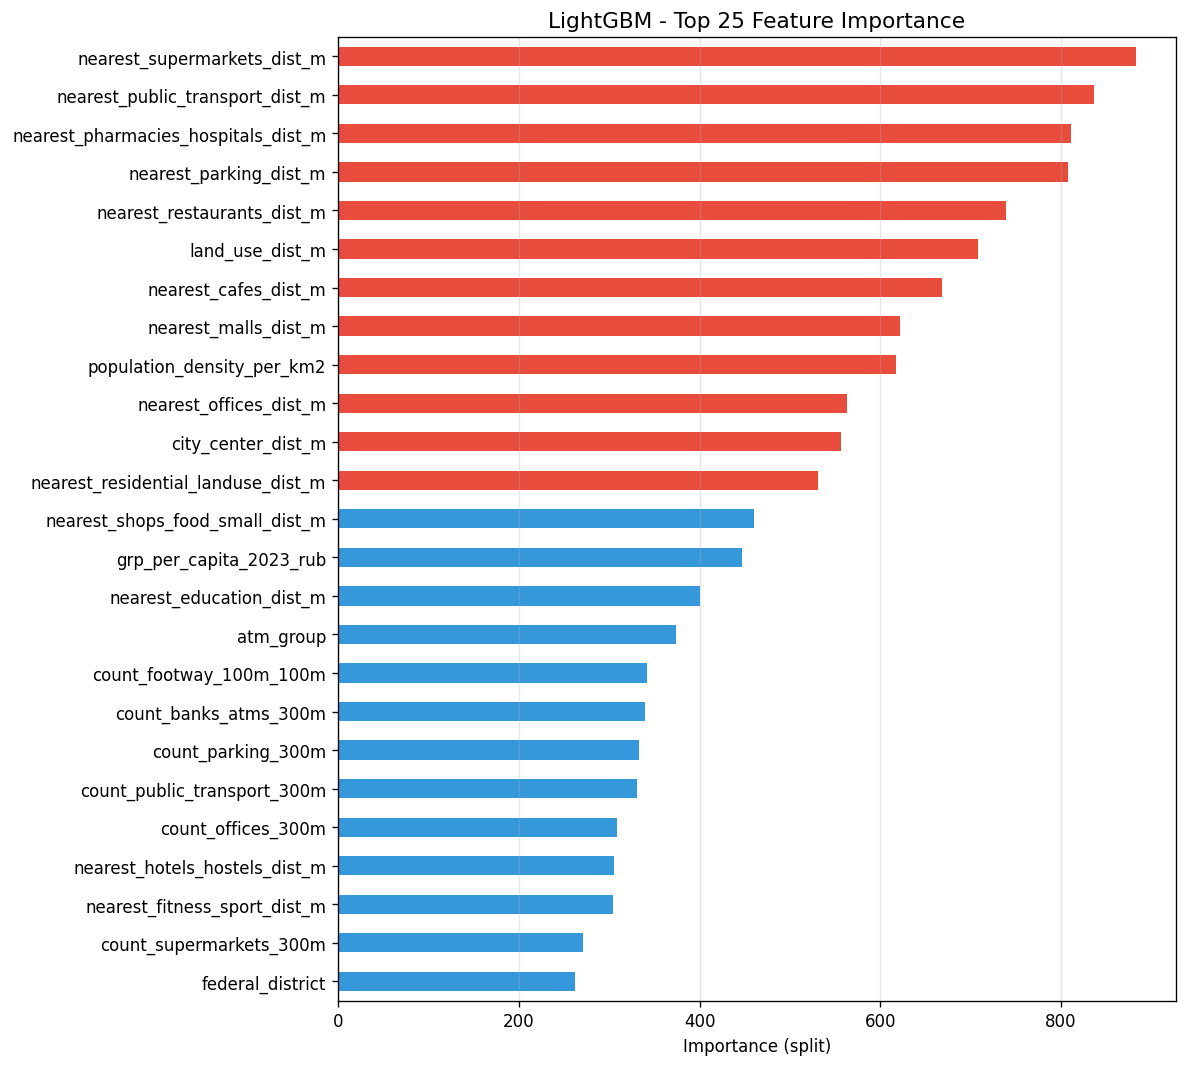


Top 15 features:
nearest_supermarkets_dist_m            883
nearest_public_transport_dist_m        836
nearest_pharmacies_hospitals_dist_m    811
nearest_parking_dist_m                 808
nearest_restaurants_dist_m             739
land_use_dist_m                        708
nearest_cafes_dist_m                   668
nearest_malls_dist_m                   622
population_density_per_km2             617
nearest_offices_dist_m                 563
city_center_dist_m                     557
nearest_residential_landuse_dist_m     531
nearest_shops_food_small_dist_m        460
grp_per_capita_2023_rub                447
nearest_education_dist_m               401


In [9]:
feat_imp = pd.Series(
    model_final.feature_importances_,
    index=X_train.columns,
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
top25 = feat_imp.head(25).iloc[::-1]
median_imp = top25.median()
colors = ['#e74c3c' if v > median_imp else '#3498db' for v in top25.values]
top25.plot.barh(ax=ax, color=colors)
ax.set_title('LightGBM - Top 25 Feature Importance', fontsize=13)
ax.set_xlabel('Importance (split)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nTop 15 features:')
print(feat_imp.head(15).to_string())

## 9. Итоги

In [ ]:
summary = pd.DataFrame([
    {'Эксперимент': 'Baseline', 'RMSE': rmse_base,  'MAE': mae_base,  'R2': r2_base,
     'Fit time, s': base_m['Fit time, s'],  'Predict time, s': base_m['Predict time, s']},
    {'Эксперимент': 'Optuna',   'RMSE': rmse_final, 'MAE': mae_final, 'R2': r2_final,
     'Fit time, s': final_m['Fit time, s'], 'Predict time, s': final_m['Predict time, s']},
]).set_index('Эксперимент')

display(
    summary.style
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R2': '{:.4f}',
             'Fit time, s': '{:.2f}', 'Predict time, s': '{:.4f}'})
    .apply(lambda s: ['font-weight: bold' if v == s.min() else '' for v in s], subset=['RMSE', 'MAE'])
    .apply(lambda s: ['font-weight: bold' if v == s.max() else '' for v in s], subset=['R2'])
)

,RMSE,MAE,R2,"Fit time, s","Predict time, s"
Эксперимент,,,,,
Baseline,0.0452,0.0360,0.7259,1.37,0.0045
Optuna,0.0448,0.0353,0.7307,0.34,0.0054



RMSE baseline: 0.0452  ->  final: 0.0448  (delta: +0.0004)
R2   baseline: 0.7259  ->  final: 0.7307
